In [1]:
import warnings
warnings.filterwarnings('ignore')

### Helper function to plot lightcurves

In [2]:
import os, glob, pandas as pd, matplotlib.pyplot as plt
from itertools import cycle

def plot_lightcurve(source_id, t_range=None, base_dir="lightcurves"):
    files = sorted(glob.glob(f"{base_dir}/*/{source_id}.csv"))
    if not files: return print(f"No data for {source_id}.")
    plt.figure(figsize=(10, 5))
    cols, mrks = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"]), cycle("os^Dvp*h<>XPdH8")
    for f in files:
        df = pd.read_csv(f, comment="#")
        if df.empty or "BJD" not in df: continue
        srv, mrk = os.path.basename(os.path.dirname(f)), next(mrks)
        for band, g in df.groupby("Filter"):
            col = next(cols)                              
            if t_range: g = g[g["BJD"].between(*t_range)]
            if g.empty: continue
            if len(g) > 1000: g = g.sample(1000, random_state=42)
            plt.errorbar(g["BJD"], g["Target_flux"], g["Target_flux_err"], fmt=mrk, color=col,
                         alpha=0.8, mec="black", mew=0.5, label=f"{srv} ({band})")
    if t_range: plt.xlim(t_range)
    plt.gca().set(xlabel="Time (BJD)", ylabel="Flux (uJy)", title=f"Light Curve: {source_id}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Query and plot data for SU Tauri

In [3]:
from lcquery import get_all_lightcurves

# SU Tauri (SU Tau)
source_id = 3398501003057791360
ra = 87.2655554543
dec = 19.0727344751

get_all_lightcurves(source_id, ra, dec, verbose=True)


--- Processing Source ID: 3398501003057791360 ---
[BlackGEM] Querying database...
[BlackGEM] No valid data found (filtered_out).
[TESS] Querying database...
[TESS] Saved 229730 observations to lightcurves/TESS/3398501003057791360.csv
[K2] Querying database...
[K2] No valid data found (no_data).
[ZTF] Querying database...
[ZTF] Saved 60 observations to lightcurves/ZTF/3398501003057791360.csv
[CRTS] Querying database...
[CRTS] Saved 23 observations to lightcurves/CRTS/3398501003057791360.csv
[NSC] Querying database...
[NSC] No valid data found (no_match).
[ATLAS] Querying database...
[ATLAS] Saved 3568 observations to lightcurves/ATLAS/3398501003057791360.csv
[SkyMapper] Querying database...
[SkyMapper] No valid data found (no_match).
[J-VAR] Querying database...
[J-VAR] No valid data found (no_match).
[ASAS-SN] Querying database...
[ASAS-SN] Saved 712 observations to lightcurves/ASAS-SN/3398501003057791360.csv
[OGLE] Querying database...
[OGLE] discovered 60 OCVS catalogues
[OGLE]   ht

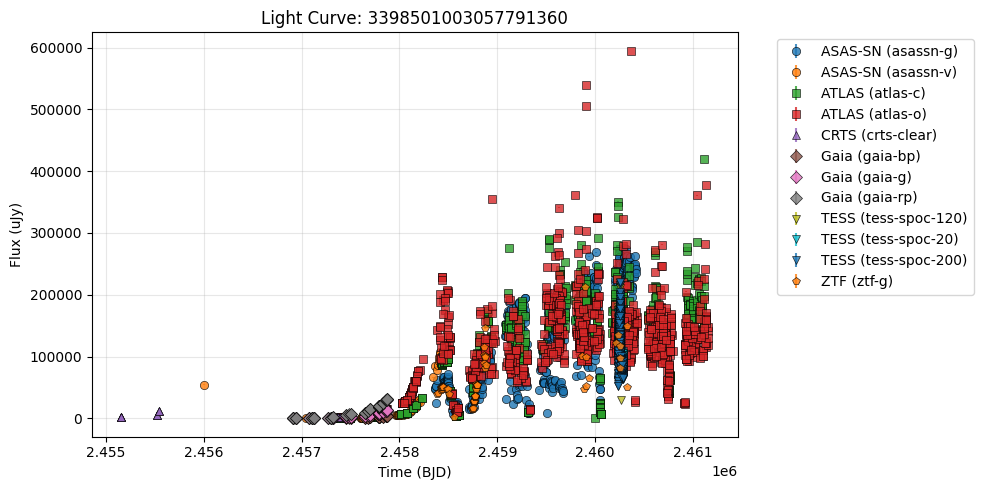

In [8]:
plot_lightcurve(source_id=3398501003057791360)

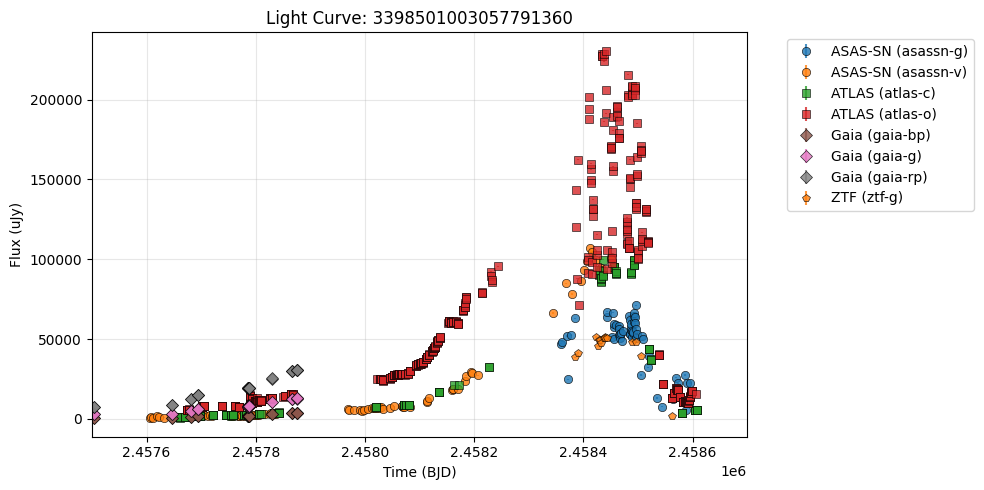

In [9]:
plot_lightcurve(source_id=3398501003057791360, t_range=[2.4575e6, 2.4587e6])

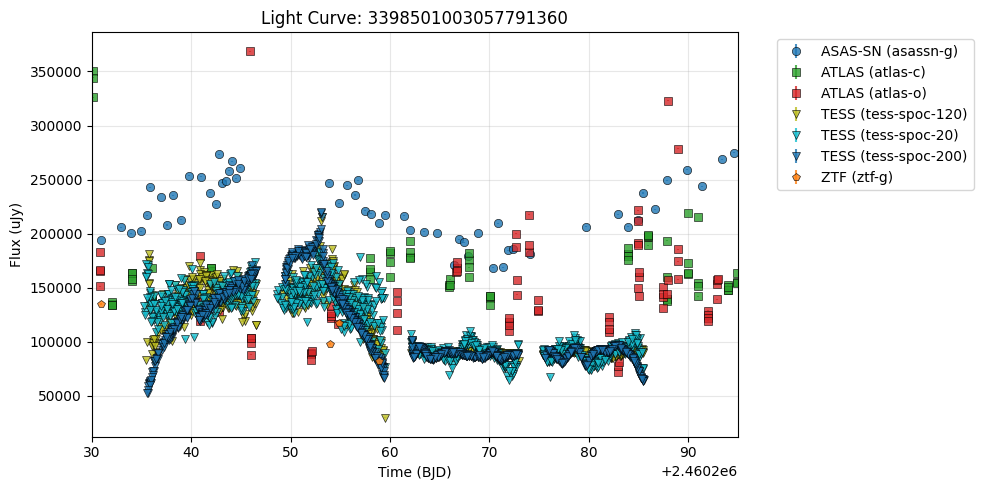

In [10]:
plot_lightcurve(source_id=3398501003057791360, t_range=[2.46023e6, 2.460295e6])